# PREDIÇÃO NO DATASET

In [1]:
import os, cv2, json, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import sys, gc
sys.path.append("..")
from Network.index import ModelNetwork
from utils.index import showTile, faciesCmaps

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu128
True
NVIDIA GeForce RTX 5070


In [3]:
models = [f'model_{i}' for i in sorted([int(path.split('_')[-1]) for path in os.listdir('Backup')])]
models 

['model_1', 'model_2', 'model_3', 'model_4', 'model_5']

In [4]:
modelId = models[-1]   # ou 'model_1' para fixar um modelo
baseDir = f'Backup/{modelId}'

if not os.path.exists(baseDir):
    print(f"Error: Model {modelId} not found at {baseDir}")

modelInfo = json.loads(open(f'{baseDir}/info.json', 'r').read())

dataset    = modelInfo.get('processing', {}).get('dataset', 'facies')
datasetDir = f'../Dataset/{dataset}'

if not os.path.exists(datasetDir):
    print(f"Error: Dataset {dataset} not found at {datasetDir}")

print(f'{modelId}: {dataset}')

model_5: facies


In [5]:
modelOptions = modelInfo.get('model', {})
print("Model Options:")
print(json.dumps(modelOptions, indent=4))

network   = ModelNetwork(**modelOptions)
modelData = torch.load(f'{baseDir}/model.pth', map_location=network.device)

network.model.load_state_dict(modelData['model'])
network.model.eval()
print(f"Weights from {modelId} loaded successfully!")

Model Options:
{
    "network": "nru_net",
    "img_size": [
        4,
        256,
        256
    ],
    "classes": 6,
    "channels": 1,
    "dropout": 0.05,
    "num_filters": 32,
    "lr": 0.0001,
    "deep_supervision": false
}
Weights from model_5 loaded successfully!


In [6]:
STEP = modelInfo['processing'].get('step')
STEP

3

In [7]:
DATABASE = f'{datasetDir}/DataBase.csv'

if not os.path.exists(DATABASE):
    raise FileNotFoundError(f'{DATABASE} nao existe. Rode o Format.ipynb de {dataset} uma vez para gera-lo.')

dfPredict = pd.read_csv(DATABASE)[['img_path', 'mask_path']]
shape     = np.load(dfPredict.img_path.iloc[0], mmap_mode='r').shape

print(f'{DATABASE}: {len(dfPredict)} tiles de shape {shape}')
dfPredict.head()

../Dataset/facies/DataBase.csv: 7074 tiles de shape (4, 256, 256)


,img_path,mask_path
0,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...
1,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...
2,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...
3,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...
4,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...


In [8]:
class PredictDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


predictDataset = PredictDataset(dfPredict)
predictLoader  = DataLoader(
    predictDataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

In [9]:
from torchmetrics.classification import MulticlassJaccardIndex

def computeIoU(network, loader):
    network.model.eval()
    network.iou.reset()
    perClass = MulticlassJaccardIndex(num_classes=network.classes, average='none').to(network.device) if network.multiclass else None

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Computing IoU"):
            imgs, masks = imgs.to(network.device), masks.to(network.device)
            logits = network.model(imgs)

            if network.multiclass:
                preds  = torch.argmax(logits, dim=1)
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                network.iou.update(preds, target)
                perClass.update(preds, target)
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                network.iou.update(preds, masks.int())

    iouValue = network.iou.compute().item()
    if perClass is not None:
        for c, v in enumerate(perClass.compute().tolist()):
            print(f"  IoU classe {c}: {v:.4f}")   # inclui a classe 0
    return iouValue


totalIoU = computeIoU(network, predictLoader)
print(f"\nMean IoU on {dataset}: {totalIoU:.4f}")

Computing IoU:   0%|                                                                                                                                                               | 0/7074 [00:00<?, ?it/s]

Computing IoU:   0%|                                                                                                                                                       | 1/7074 [00:00<28:22,  4.16it/s]

Computing IoU:   0%|                                                                                                                                                       | 5/7074 [00:00<07:18, 16.11it/s]

Computing IoU:   0%|▏                                                                                                                                                      | 9/7074 [00:00<05:17, 22.25it/s]

Computing IoU:   0%|▎                                                                                                                                                     | 13/7074 [00:00<04:33, 25.80it/s]

...

Computing IoU: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 7065/7074 [03:39<00:00, 32.25it/s]

Computing IoU: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 7069/7074 [03:39<00:00, 32.24it/s]

Computing IoU: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 7073/7074 [03:39<00:00, 32.21it/s]

Computing IoU: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7074/7074 [03:39<00:00, 32.21it/s]

  IoU classe 0: 0.9897
  IoU classe 1: 0.9202
  IoU classe 2: 0.9422
  IoU classe 3: 0.9549
  IoU classe 4: 0.9412
  IoU classe 5: 0.9960

Mean IoU on facies: 0.9574


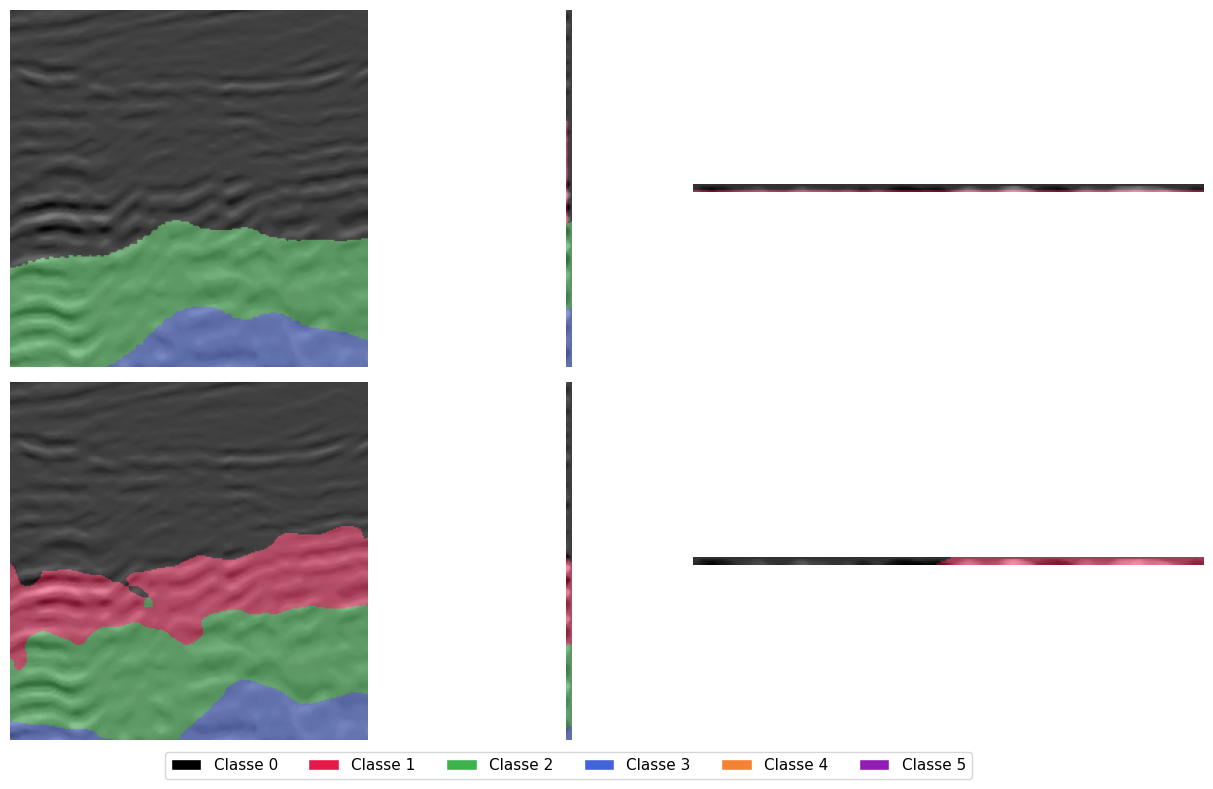

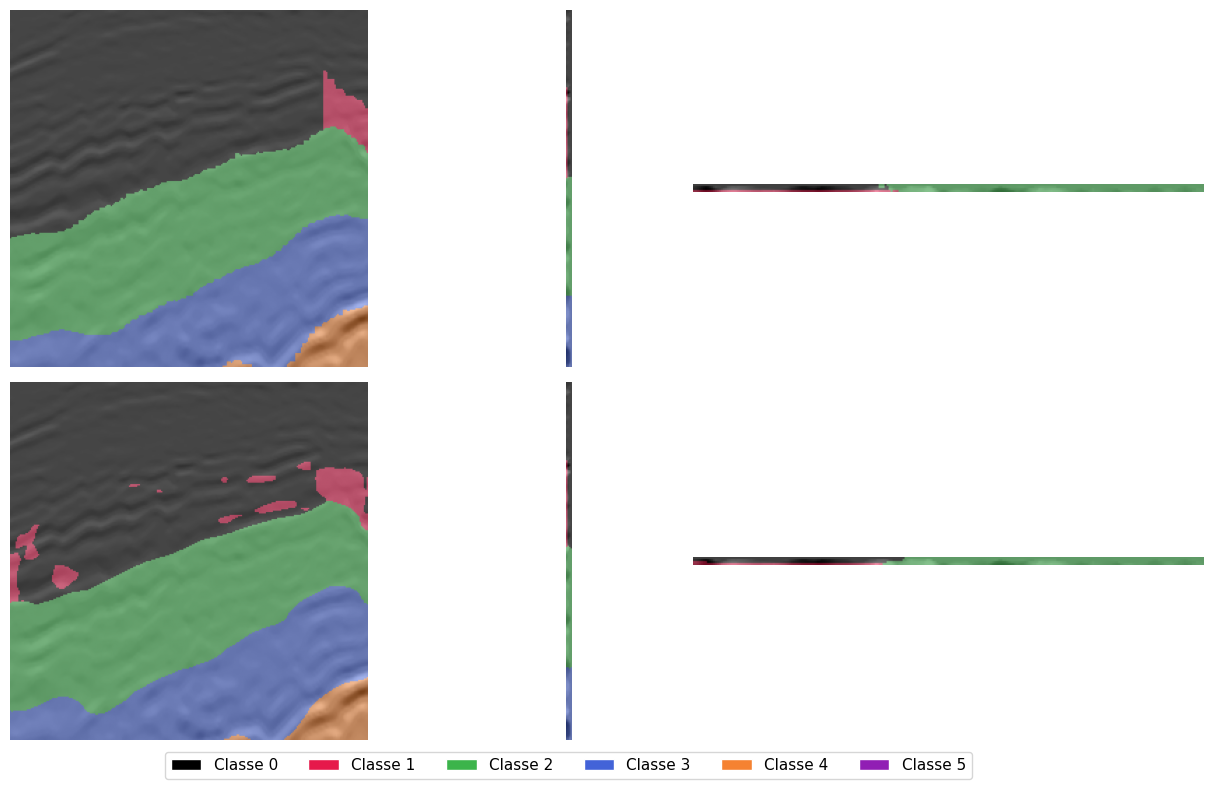

In [10]:
def plotPrediction(index, dataset=predictDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits    = network.model(img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    if network.multiclass:
        solid_cmap, cmap = faciesCmaps(network.classes)
        mx, my, mz = img_np.shape[0] // 2, img_np.shape[1] // 2, img_np.shape[2] // 2
        planes = lambda v: [np.array(v[mx, :, :]), np.rot90(np.array(v[:, :, mz]), -1), np.array(v[:, my, :])]
        ig, mg, pg = planes(img_np), planes(mask_np), planes(pred_np)

        fig, axes = plt.subplots(2, 3, figsize=(13, 8))
        for j in range(3):
            for r, layer in enumerate([mg, pg]):
                axes[r, j].imshow(ig[j], cmap='gray')
                axes[r, j].imshow(layer[j], cmap=cmap, vmin=0, vmax=network.classes - 1, alpha=alpha)
                axes[r, j].axis('off')

        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=solid_cmap.colors[i], edgecolor='white', label=f'Classe {i}') for i in range(network.classes)]
        fig.legend(handles=legend_elements, loc='lower center', ncol=min(network.classes, 7), bbox_to_anchor=(0.5, 0.01), fontsize=11)

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        if savePath:
            plt.savefig(savePath, bbox_inches='tight', dpi=200); plt.close(fig)
        else:
            plt.show()
        return

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    inters  = (is_gt & is_pred)   # Acertos / Interseção

    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)
        

for i in range(min(len(predictDataset), 2)):
    plotPrediction(index=i)

# PREDIÇÃO DO VOLUME INTEIRO

In [11]:
class PredictBuilder:
    def __init__(self, target_size, classes, save_path=None):
        self.tz, self.ty, self.tx = target_size
        self.classes   = classes
        self.save_path = save_path

    def process(self, vol):
        pads = [(0, (s - vol.shape[i] % s) % s) for i, s in enumerate((self.tz, self.ty, self.tx))]
        if all(p == 0 for _, p in pads): return vol
        return np.pad(vol, pads, mode='reflect')

    def update(self):
        network.model.eval()
        self.pred  = np.zeros(seismic.shape, dtype=np.uint8)
        self.inter = np.zeros(self.classes, dtype=np.int64)
        self.union = np.zeros(self.classes, dtype=np.int64)

        for z in tqdm(range(0, seismic.shape[0], self.tz)):
            # AS FATIAS DE TREINO (UMA A CADA STEP, COMO O Format CORTA) FICAM DE FORA: O IOU E SO DO QUE A REDE NAO VIU
            if (z // self.tz) % STEP == 0:
                continue

            src = np.asarray(seismic[z:z + self.tz], dtype=np.float32)
            if src.shape[0] == 0: break

            img = self.process(src)
            res = np.zeros(img.shape, dtype=np.uint8)

            for y in range(0, img.shape[1], self.ty):
                for x in range(0, img.shape[2], self.tx):
                    it = img[:, y:y + self.ty, x:x + self.tx]

                    imgTensor = torch.tensor(it).unsqueeze(0).unsqueeze(0).to(network.device)
                    with torch.no_grad():
                        logits = network.model(imgTensor)
                        pred = torch.argmax(logits, dim=1).squeeze(0).squeeze(0) if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze(0).squeeze(0).int()

                    res[:, y:y + self.ty, x:x + self.tx] = pred.cpu().numpy()

            orig_z = src.shape[0]
            block  = res[:orig_z, :seismic.shape[1], :seismic.shape[2]]
            self.pred[z:z + orig_z] = block

            # iou incremental do volume inteiro (inclui a classe 0)
            gt = np.asarray(masks[z:z + orig_z]).astype(np.uint8)
            for c in range(self.classes):
                pm, gm = (block == c), (gt == c)
                self.inter[c] += np.count_nonzero(pm & gm)
                self.union[c] += np.count_nonzero(pm | gm)

        if self.save_path:
            np.save(self.save_path, self.pred)

    def iou(self):
        vals = self.inter / np.maximum(self.union, 1)
        data = {str(c): float(v) for c, v in enumerate(vals)}
        data['mean'] = float(vals.mean())
        return data


RAW_DIR      = f'{datasetDir}/files/'
SEISMIC_PATH = os.path.join(RAW_DIR, 'marlim_norm_perc_1-99_cut.npy')
MASK_PATH    = os.path.join(RAW_DIR, 'npy_multiclass_cut.npy')
SAVE_PRED    = False   # opcional: salva predicted.npy (~3.5 GB) no backup

seismic = np.load(SEISMIC_PATH, mmap_mode='r')
masks   = np.load(MASK_PATH, mmap_mode='r')

builder = PredictBuilder(network.img_size, network.classes, save_path=os.path.join(baseDir, 'predicted.npy') if SAVE_PRED else None)
builder.update()
builder.pred.shape

  0%|                                                                                                                                                                               | 0/785 [00:00<?, ?it/s]

  0%|▍                                                                                                                                                                      | 2/785 [00:00<05:26,  2.40it/s]

  0%|▋                                                                                                                                                                      | 3/785 [00:01<07:42,  1.69it/s]

  1%|█                                                                                                                                                                      | 5/785 [00:02<06:27,  2.01it/s]

  1%|█▎                                                                                                                                                                     | 6/785 [00:03<07:40,  1.69it/s]

...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎| 782/785 [07:12<00:01,  1.91it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌| 783/785 [07:13<00:01,  1.70it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 785/785 [07:14<00:00,  1.92it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 785/785 [07:14<00:00,  1.81it/s]

(3137, 552, 2050)

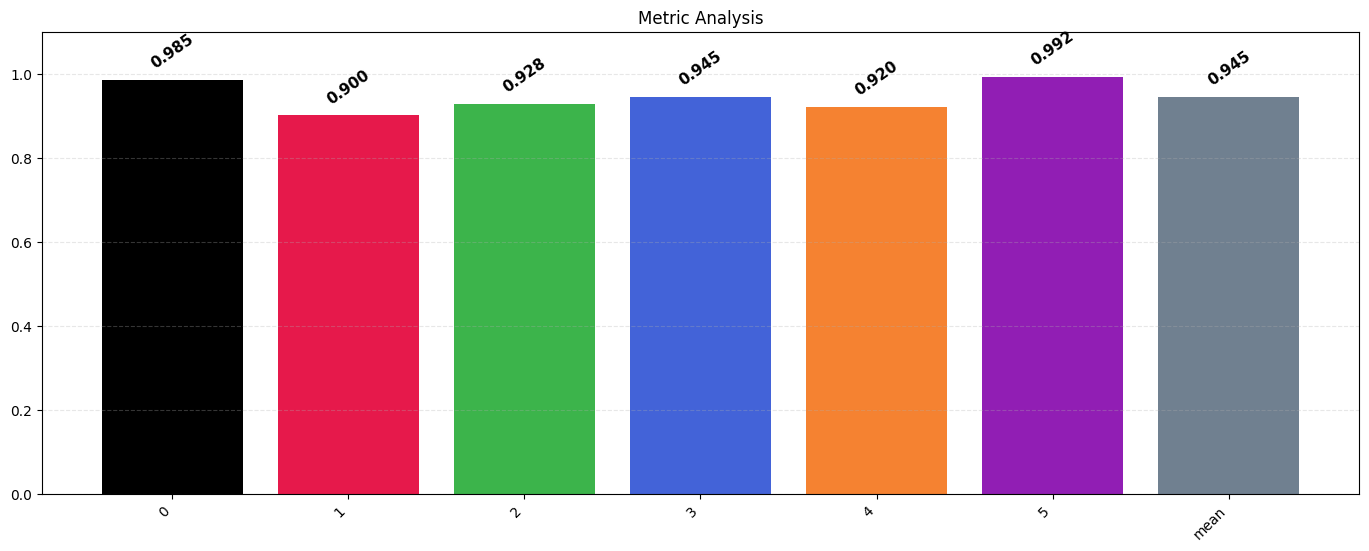

In [12]:
from utils.Plotter.index import Plotter

marlimIoU = builder.iou()
modelInfo['marlim_iou'] = marlimIoU

with open(f'{baseDir}/info.json', 'w', encoding='utf-8') as f:
    json.dump(modelInfo, f, ensure_ascii=False, indent=4)

# Gráfico por classe do bloco inteiro (ordenado por índice da classe: 0 a N, 'mean' no final)
class_keys = sorted([k for k in marlimIoU.keys() if k != 'mean'], key=lambda x: int(x) if x.isdigit() else x)
ious = {k: marlimIoU[k] for k in class_keys}
if 'mean' in marlimIoU:
    ious['mean'] = marlimIoU['mean']

plt.figure(figsize=(17, 6))
Plotter(ious)
plt.savefig(os.path.join(baseDir, 'marlim_classes.png'))
plt.show()

# COMPARAÇÃO VISUAL

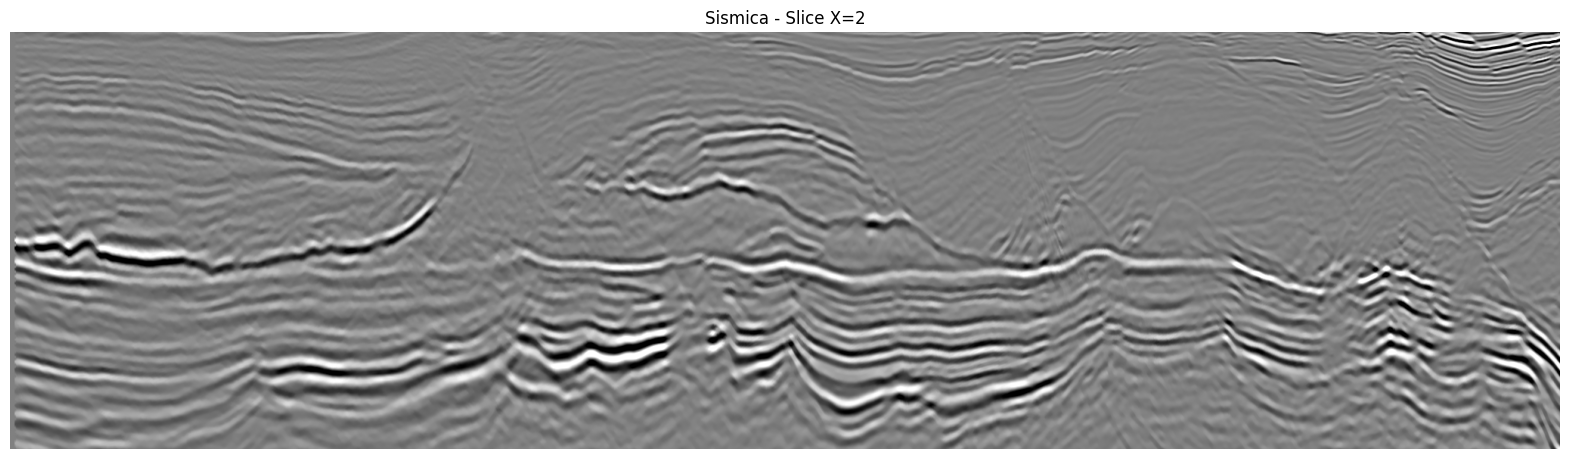

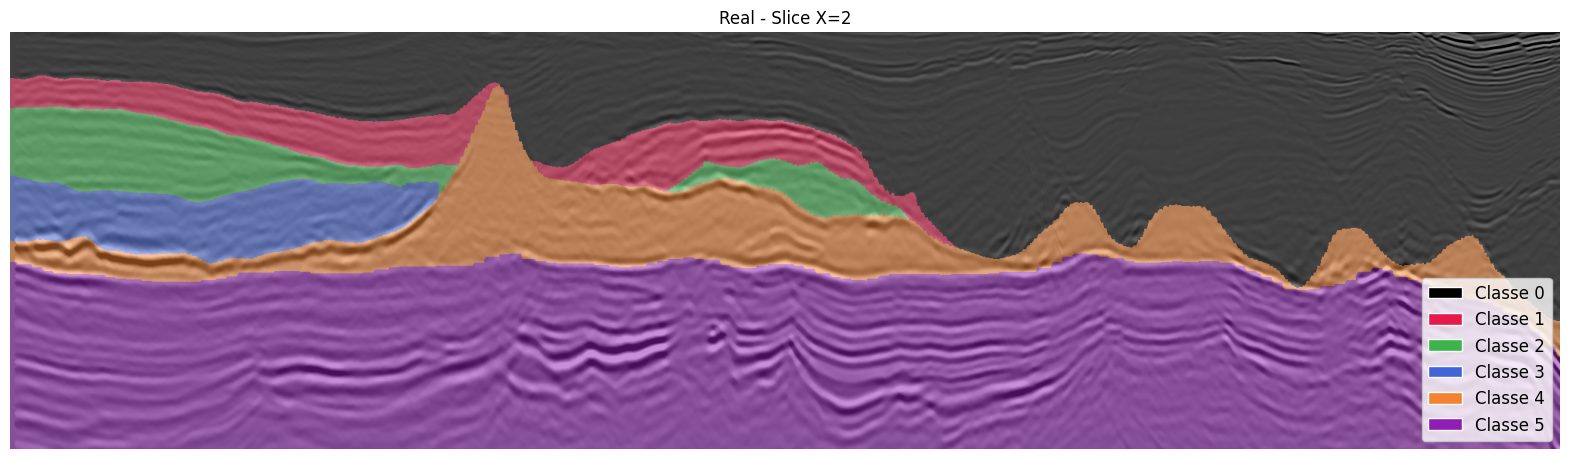

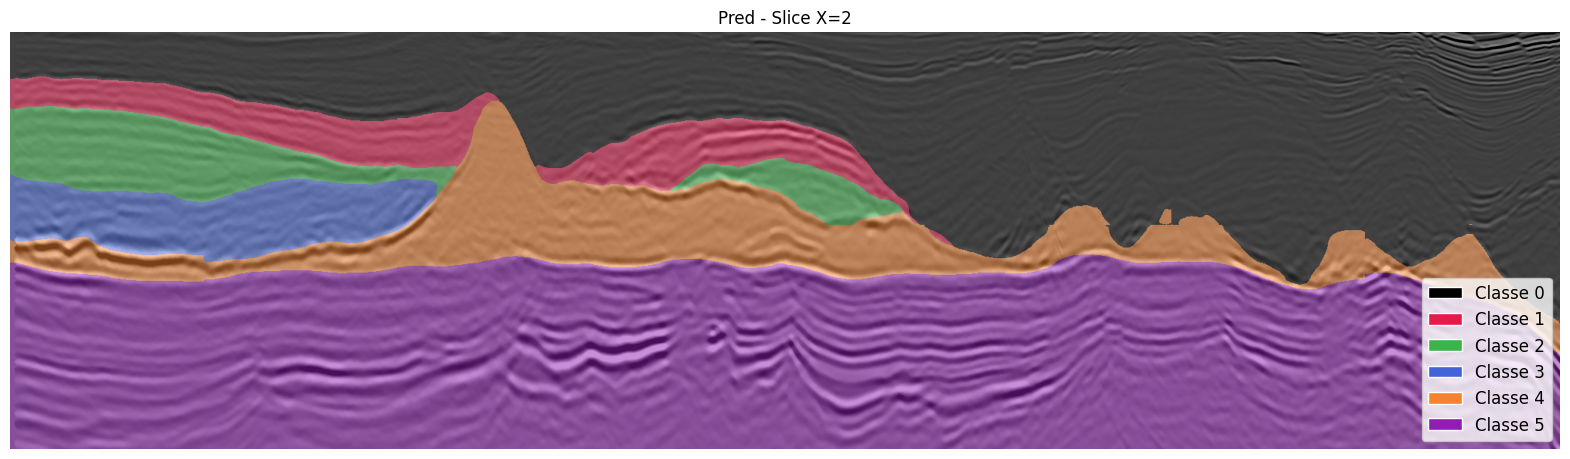

In [13]:
def plotViews(img, mask, pred, alpha=0.5, saveDir=None):
    from matplotlib.patches import Patch
    mx = img.shape[0] // 2
    ig = np.array(img[mx, :, :])
    mg = np.array(mask[mx, :, :])
    pg = np.array(pred[mx, :, :])
    solid_cmap, cmap = faciesCmaps(network.classes)

    for name, layer in [('sismica', None), ('real', mg), ('pred', pg)]:
        plt.figure(figsize=(20, 10))
        plt.imshow(ig, cmap='gray')

        if layer is not None:
            plt.imshow(layer, cmap=cmap, vmin=0, vmax=network.classes - 1, alpha=alpha)
            legend_elements = [Patch(facecolor=solid_cmap.colors[i], edgecolor='white', label=f'Classe {i}') for i in range(network.classes)]
            plt.legend(handles=legend_elements, loc='lower right', fontsize=12)

        plt.title(f"{name.capitalize()} - Slice X={mx}"); plt.axis('off')
        if saveDir:
            plt.savefig(os.path.join(saveDir, f'volume_{name}.png'), dpi=200, bbox_inches='tight')
        plt.show()


viewsDir = os.path.join(baseDir, 'views')
os.makedirs(viewsDir, exist_ok=True)

tz   = builder.tz
ix   = (seismic.shape[0] // 2) // tz * tz
ix   = (ix + tz) if (ix // tz) % STEP == 0 else ix   # fatia do meio que a rede nao viu (as de treino ficam sem predicao)
img  = np.asarray(seismic[ix:ix+tz], dtype=np.float32)
mask = np.asarray(masks[ix:ix+tz], dtype=np.uint8)
pred = builder.pred[ix:ix+tz]
plotViews(img, mask, pred, saveDir=viewsDir)